<a href="https://colab.research.google.com/github/jerry124/Aprendizaje-Automatico/blob/main/Practica_Final_Regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica final: Regresión Lineal con el dataset Advertising

**Autor:** Gerardo Valdez Martínez  
**Objetivo general:** construir un modelo de regresión lineal para predecir las ventas de un producto a partir de la inversión en publicidad en **TV**, **Radio** y **Newspaper**.


## 1. Contexto del problema

El dataset contiene información sobre inversión publicitaria en tres medios diferentes:

- **TV:** inversión en publicidad por televisión.
- **Radio:** inversión en publicidad por radio.
- **Newspaper:** inversión en publicidad en periódicos.
- **Sales:** ventas del producto.

La pregunta principal es:

> ¿Podemos predecir las ventas de un producto a partir del presupuesto invertido en publicidad?

Como la variable que queremos predecir (**Sales**) es numérica continua, el problema corresponde a una tarea de **regresión**.

## 2. Importación de librerías

Primero importamos las librerías necesarias para cargar datos, analizarlos, graficarlos, entrenar el modelo y evaluar su desempeño.

In [ ]:
# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Separación de datos y modelo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Métricas de evaluación
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configuración visual
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## 3. Carga de la base de datos

Se carga el archivo `Advertising.csv`. Esta base será utilizada para entrenar un modelo que relacione la inversión publicitaria con las ventas.

In [ ]:
# Cargar el dataset

df = pd.read_csv('Advertising.csv')

# Mostrar las primeras filas
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## 4. Limpieza inicial de los datos

En algunos archivos aparece una columna llamada `Unnamed: 0`, que solamente representa un índice y no aporta información real al modelo. Por eso se elimina.

Esta decisión es importante porque esa columna no representa una variable explicativa del problema.

In [ ]:
# Eliminar columna de índice si existe
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Confirmar las columnas finales
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## 5. Exploración general del dataset

Antes de entrenar cualquier modelo, es importante conocer la estructura de la base de datos: número de filas, columnas, tipos de datos y valores faltantes.

In [ ]:
print('Filas y columnas:', df.shape)

# Información general
print('\nInformación del dataset:')
df.info()

Filas y columnas: (200, 4)

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [ ]:
# Verificar valores nulos
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


### Interpretación

Si no existen valores nulos, no es necesario aplicar técnicas de imputación. Esto permite trabajar directamente con los datos originales, evitando modificar artificialmente la información.

## 6. Estadística descriptiva

La estadística descriptiva nos permite observar el comportamiento general de cada variable: promedio, desviación estándar, valores mínimos y máximos.

In [ ]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


## 7. Análisis visual de las variables

Primero observamos la distribución de cada variable para entender cómo se comportan los datos.

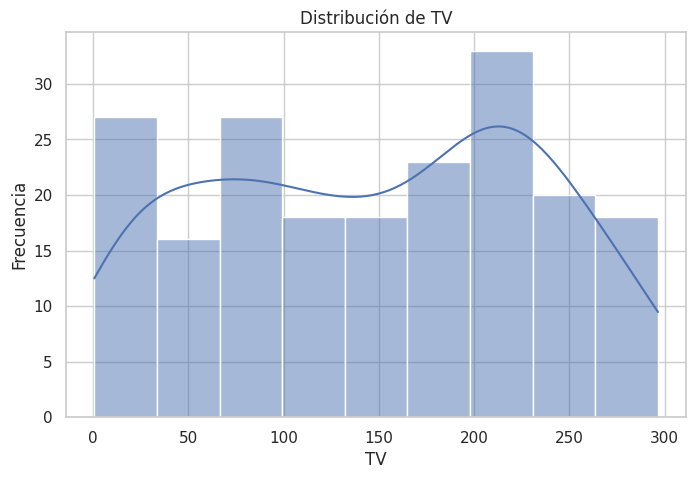

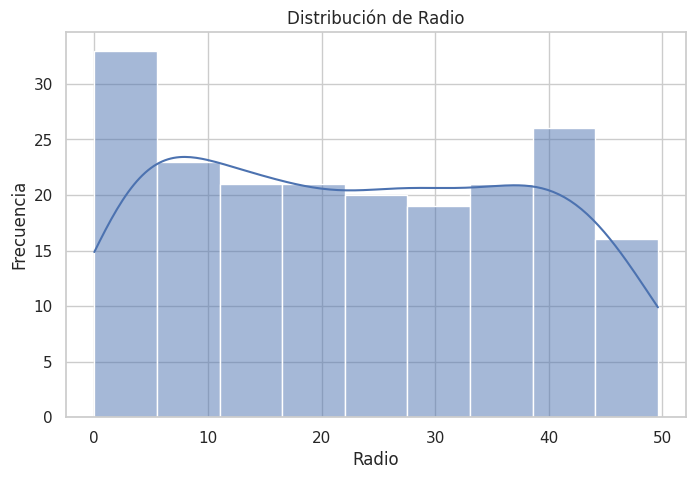

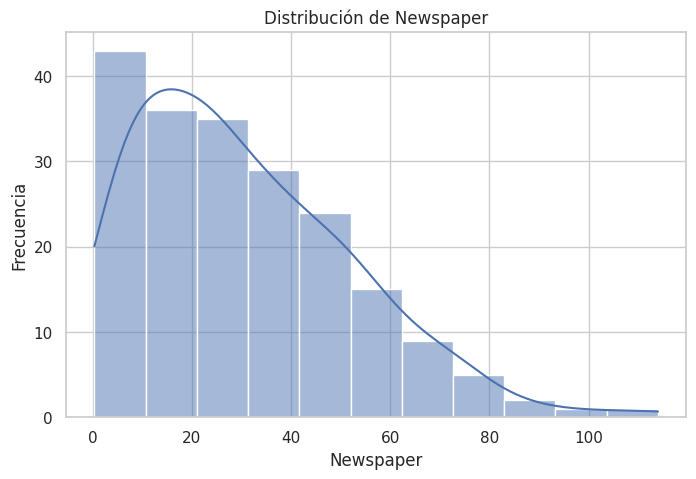

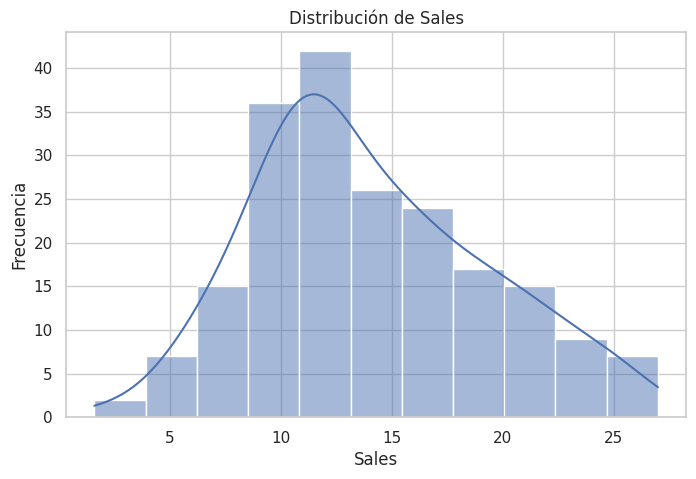

In [ ]:
# Histogramas de las variables
for col in df.columns:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.show()

## 8. Relación entre publicidad y ventas

Ahora se analiza visualmente cómo se relaciona cada medio publicitario con las ventas. Esto permite observar si existe una tendencia lineal.

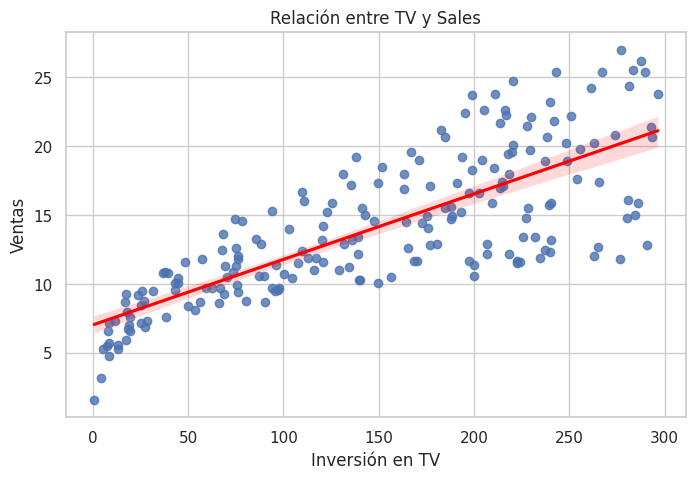

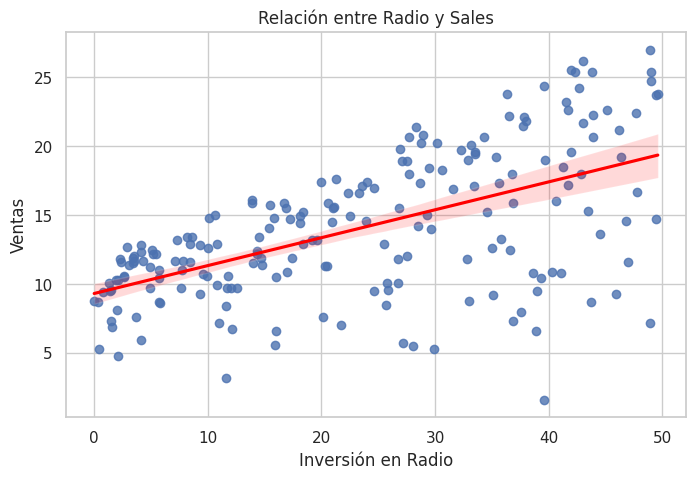

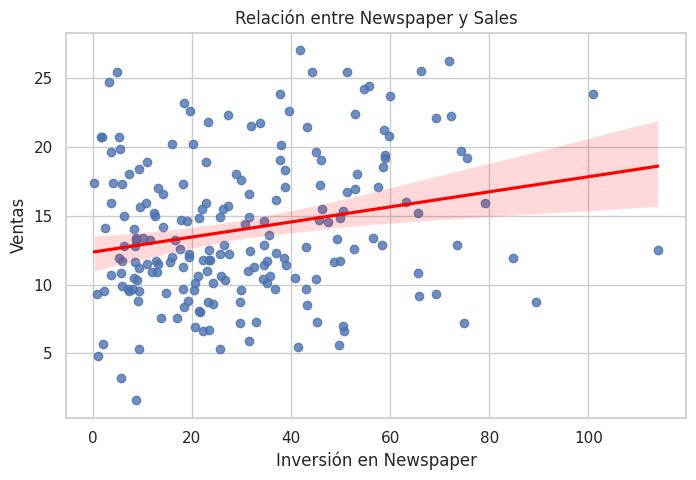

In [ ]:
# Gráficas de dispersión con línea de tendencia
variables = ['TV', 'Radio', 'Newspaper']

for col in variables:
    plt.figure()
    sns.regplot(data=df, x=col, y='Sales', line_kws={'color': 'red'})
    plt.title(f'Relación entre {col} y Sales')
    plt.xlabel(f'Inversión en {col}')
    plt.ylabel('Ventas')
    plt.show()

### Interpretación esperada

- **TV** suele mostrar una relación positiva clara con las ventas.
- **Radio** también puede presentar una relación positiva importante.
- **Newspaper** normalmente muestra una relación más débil.

Esto significa que no todas las variables tienen el mismo peso para explicar las ventas.

## 9. Matriz de correlación

La correlación mide qué tan relacionadas están dos variables. Valores cercanos a 1 indican relación positiva fuerte; valores cercanos a 0 indican relación débil.

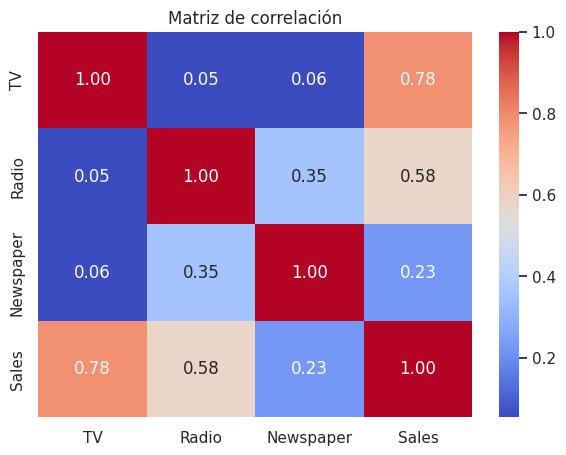

,Sales
Sales,1.000000
TV,0.782224
Radio,0.576223
Newspaper,0.228299


In [ ]:
# Matriz de correlación
corr = df.corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

corr['Sales'].sort_values(ascending=False)

## 10. Definición de variables predictoras y variable objetivo

Para entrenar el modelo se separan las variables:

- **X:** variables de entrada o predictoras: `TV`, `Radio`, `Newspaper`.
- **y:** variable de salida u objetivo: `Sales`.

In [ ]:
X = df[['TV', 'Radio', 'Newspaper']]

# Variable objetivo
y = df['Sales']

print('Variables predictoras:')
print(X.head())

print('\nVariable objetivo:')
print(y.head())

Variables predictoras:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Variable objetivo:
0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


## 11. Separación en entrenamiento y prueba

Se divide la base de datos en dos partes:

- **80% entrenamiento:** datos que usa el modelo para aprender.
- **20% prueba:** datos nuevos para evaluar si el modelo generaliza correctamente.

Esta separación evita evaluar el modelo con los mismos datos con los que fue entrenado.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Tamaño de X_train:', X_train.shape)
print('Tamaño de X_test:', X_test.shape)
print('Tamaño de y_train:', y_train.shape)
print('Tamaño de y_test:', y_test.shape)

Tamaño de X_train: (160, 3)
Tamaño de X_test: (40, 3)
Tamaño de y_train: (160,)
Tamaño de y_test: (40,)


## 12. Entrenamiento del modelo de regresión lineal

La regresión lineal busca encontrar una ecuación que relacione las variables de entrada con las ventas.

La forma general del modelo es:

\[
Sales = b_0 + b_1(TV) + b_2(Radio) + b_3(Newspaper)
\]

Donde:

- \(b_0\) es el intercepto.
- \(b_1\), \(b_2\) y \(b_3\) son los coeficientes de cada variable.

Estos coeficientes indican cuánto cambia la predicción de ventas cuando aumenta una variable, manteniendo las demás constantes.

In [ ]:
# Crear el modelo
modelo = LinearRegression()

# Entrenar el modelo
modelo.fit(X_train, y_train)

print('Modelo entrenado correctamente.')

Modelo entrenado correctamente.


## 13. Coeficientes del modelo

Los coeficientes permiten interpretar la importancia de cada variable dentro del modelo lineal.

In [ ]:
# Mostrar intercepto y coeficientes
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_
})

print('Intercepto:', modelo.intercept_)
coeficientes

Intercepto: 2.979067338122629


,Variable,Coeficiente
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


### Interpretación de coeficientes

Cada coeficiente representa el cambio esperado en **Sales** cuando esa variable aumenta una unidad, manteniendo las demás constantes.

Por ejemplo:

- Si el coeficiente de **TV** es positivo, significa que al aumentar la inversión en TV, las ventas tienden a aumentar.
- Si el coeficiente de **Radio** es positivo, también contribuye al incremento de ventas.
- Si **Newspaper** tiene un coeficiente muy pequeño, su efecto en el modelo es menor.

## 14. Predicciones del modelo

Una vez entrenado el modelo, se realizan predicciones sobre los datos de prueba.

In [ ]:
# Predicciones con datos de prueba
y_pred = modelo.predict(X_test)

# Comparar valores reales vs predichos
comparacion = pd.DataFrame({
    'Ventas reales': y_test.values,
    'Ventas predichas': y_pred,
    'Error': y_test.values - y_pred
})

comparacion.head(10)

,Ventas reales,Ventas predichas,Error
0,16.9,16.408024,0.491976
1,22.4,20.889882,1.510118
2,21.4,21.553843,-0.153843
3,7.3,10.608503,-3.308503
4,24.7,22.112373,2.587627
5,12.6,13.105592,-0.505592
6,22.3,21.057192,1.242808
7,8.4,7.461010,0.938990
8,11.5,13.606346,-2.106346
9,14.9,15.155070,-0.255070


## 15. Evaluación del modelo

Para saber qué tan bueno es el modelo, se utilizan diferentes métricas:

- **MAE:** error absoluto promedio.
- **MSE:** error cuadrático medio.
- **RMSE:** raíz del error cuadrático medio.
- **R²:** porcentaje de variabilidad de las ventas explicado por el modelo.

In [ ]:
# Cálculo de métricas
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('MAE:', round(mae, 4))
print('MSE:', round(mse, 4))
print('RMSE:', round(rmse, 4))
print('R²:', round(r2, 4))

MAE: 1.4608
MSE: 3.1741
RMSE: 1.7816
R²: 0.8994


### Interpretación de las métricas

- Un **MAE bajo** indica que, en promedio, las predicciones se alejan poco de los valores reales.
- El **RMSE** penaliza más los errores grandes.
- El **R²** indica qué porcentaje de la variación de las ventas puede explicar el modelo.

Por ejemplo, si el R² es cercano a 0.90, significa que el modelo explica aproximadamente el 90% de la variabilidad de las ventas.

## 16. Comparación visual: ventas reales vs ventas predichas

Esta gráfica permite observar si las predicciones se acercan a los valores reales. Mientras más cerca estén los puntos de la línea roja, mejor es el modelo.

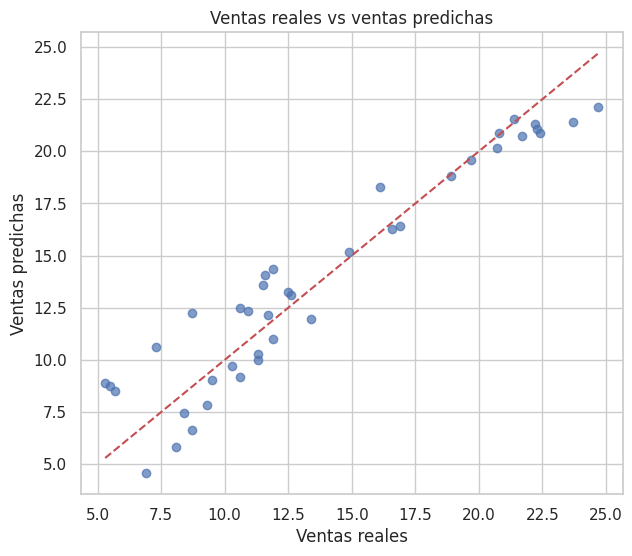

In [ ]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Ventas reales')
plt.ylabel('Ventas predichas')
plt.title('Ventas reales vs ventas predichas')
plt.show()

## 17. Análisis de residuos

Los residuos son la diferencia entre el valor real y el valor predicho. Sirven para observar si el modelo está cometiendo errores de manera aleatoria o si existe algún patrón.

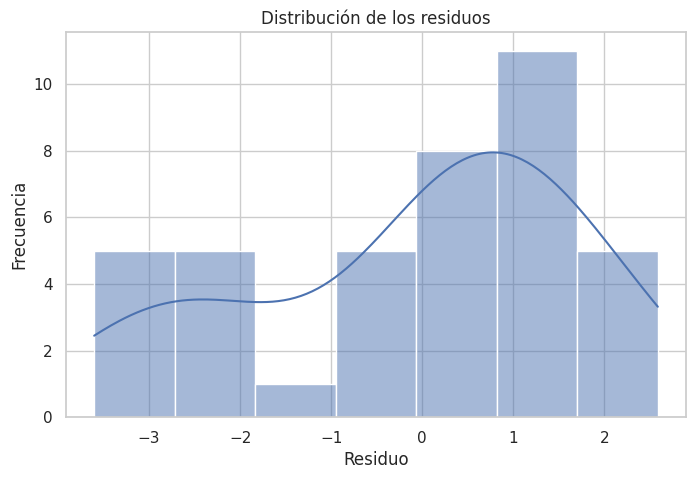

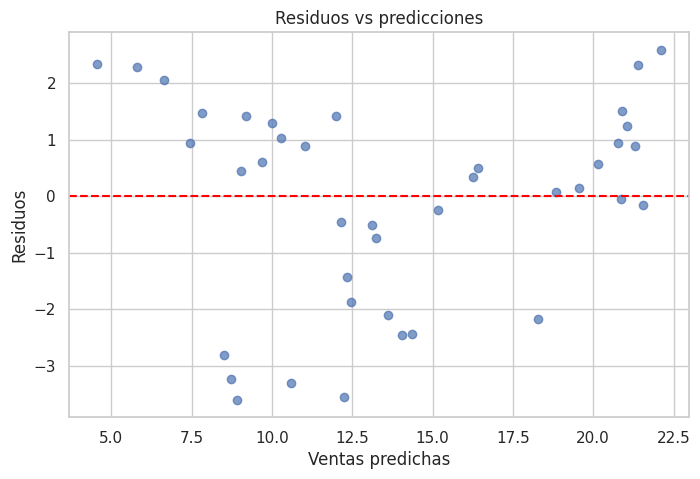

In [ ]:
residuos = y_test - y_pred

plt.figure()
sns.histplot(residuos, kde=True)
plt.title('Distribución de los residuos')
plt.xlabel('Residuo')
plt.ylabel('Frecuencia')
plt.show()

plt.figure()
plt.scatter(y_pred, residuos, alpha=0.7)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Ventas predichas')
plt.ylabel('Residuos')
plt.title('Residuos vs predicciones')
plt.show()

## 18. Modelo alternativo sin Newspaper

Como `Newspaper` suele tener una relación más débil con las ventas, se puede probar un segundo modelo usando solo `TV` y `Radio`.

Esto permite comparar si eliminar una variable poco relacionada mejora o mantiene el rendimiento.

In [ ]:
# Modelo usando solo TV y Radio
X2 = df[['TV', 'Radio']]
y2 = df['Sales']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, random_state=42
)

modelo_2 = LinearRegression()
modelo_2.fit(X2_train, y2_train)

y2_pred = modelo_2.predict(X2_test)

mae_2 = mean_absolute_error(y2_test, y2_pred)
mse_2 = mean_squared_error(y2_test, y2_pred)
rmse_2 = np.sqrt(mse_2)
r2_2 = r2_score(y2_test, y2_pred)

resultados = pd.DataFrame({
    'Modelo': ['TV + Radio + Newspaper', 'TV + Radio'],
    'MAE': [mae, mae_2],
    'MSE': [mse, mse_2],
    'RMSE': [rmse, rmse_2],
    'R²': [r2, r2_2]
})

resultados

,Modelo,MAE,MSE,RMSE,R²
0,TV + Radio + Newspaper,1.460757,3.174097,1.781600,0.899438
1,TV + Radio,1.444302,3.137948,1.771425,0.900583


### Interpretación del modelo alternativo

Si el modelo con solo **TV** y **Radio** obtiene un rendimiento muy parecido al modelo completo, se puede concluir que **Newspaper** no aporta demasiada información para la predicción de ventas.

Esto no significa que la variable sea incorrecta, sino que su impacto dentro de este modelo lineal es menor.

## 19. Conclusión general

En esta práctica se construyó un modelo de regresión lineal para predecir las ventas de un producto a partir de la inversión publicitaria en TV, Radio y Newspaper.

Los resultados muestran que la regresión lineal es adecuada para este problema porque existe una relación positiva entre la inversión publicitaria y las ventas. Las variables **TV** y **Radio** presentan mayor influencia en la predicción, mientras que **Newspaper** tiene una aportación menor.

El valor de **R²** permite afirmar que el modelo explica una parte importante del comportamiento de las ventas. Además, al comparar el modelo completo con un modelo simplificado, se puede justificar si conviene conservar todas las variables o trabajar únicamente con las más relevantes.

En conclusión, el modelo permite estimar las ventas de forma clara, interpretable y útil, cumpliendo con el objetivo de aplicar regresión lineal a un problema real de predicción.


Una forma sencilla de explicar esta práctica sería:

> En este proyecto utilicé una base de datos de publicidad para predecir las ventas de un producto. Las variables de entrada fueron la inversión en TV, Radio y Newspaper, mientras que la variable objetivo fue Sales. Primero revisé los datos, confirmé que no hubiera valores nulos y analicé la relación entre las variables. Después entrené un modelo de regresión lineal, evalué su desempeño con MAE, MSE, RMSE y R², y finalmente comparé un modelo completo contra uno simplificado. Los resultados muestran que TV y Radio son las variables que más aportan a la predicción de ventas.